In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import os
import glob
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
# ==========================================
# CELL 2 - CHECK CURRENT JUPYTER LOCATION
# ==========================================

print("Current working directory:")
print(os.getcwd())

print("\nFiles available in this folder:")

for file in os.listdir():
    print(file)

Current working directory:
/home/8d98f00b-8c22-4042-a47e-a72e125975f3

Files available in this folder:
.local
.jupyter
.pythonstartup.py
.cache
.ipython
eVechicle.ipynb
README.ipynb
.vimrc
anaconda_projects
.anaconda
Electric Vehicle Sales by State in India (1).csv
.conda
.npm
.virtualenvs
.gitconfig
.ipynb_checkpoints
.config
.profile
.bashrc


In [8]:
# ==========================================
# CELL 3 - FIND CSV FILE AUTOMATICALLY
# ==========================================

csv_files = glob.glob("*.csv")

print("CSV files found:")

for file in csv_files:
    print(file)

if len(csv_files) == 0:
    print("\n❌ No CSV file found!")
else:
    print("\n✅ CSV file found!")

CSV files found:
Electric Vehicle Sales by State in India (1).csv

✅ CSV file found!


In [9]:
# ==========================================
# CELL 4 - LOAD DATASET
# ==========================================

if len(csv_files) == 1:
    
    file_path = csv_files[0]
    df = pd.read_csv(file_path)
    
    print("Dataset loaded successfully!")
    print("File:", file_path)

elif len(csv_files) > 1:
    
    print("Multiple CSV files found:")
    
    for i, file in enumerate(csv_files):
        print(i, "-", file)
    
    # Select the first CSV
    file_path = csv_files[0]
    df = pd.read_csv(file_path)
    
    print("\nUsing:", file_path)

else:
    print("❌ CSV file not found.")

Dataset loaded successfully!
File: Electric Vehicle Sales by State in India (1).csv


In [10]:
# ==========================================
# CELL 5 - BASIC DATASET CHECK
# ==========================================

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape:
(96845, 8)

Column Names:
['Year', 'Month_Name', 'Date', 'State', 'Vehicle_Class', 'Vehicle_Category', 'Vehicle_Type', 'EV_Sales_Quantity']

First 5 Rows:


,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
0,2014.0,jan,1/1/2014,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0.0
1,2014.0,jan,1/1/2014,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0.0
2,2014.0,jan,1/1/2014,Andhra Pradesh,AMBULANCE,Others,Others,0.0
3,2014.0,jan,1/1/2014,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0.0
4,2014.0,jan,1/1/2014,Andhra Pradesh,BUS,Bus,Bus,0.0


In [11]:
# ==========================================
# CELL 6 - DATASET INFORMATION
# ==========================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               96845 non-null  float64
 1   Month_Name         96845 non-null  object 
 2   Date               96845 non-null  object 
 3   State              96845 non-null  object 
 4   Vehicle_Class      96845 non-null  object 
 5   Vehicle_Category   96845 non-null  object 
 6   Vehicle_Type       96845 non-null  object 
 7   EV_Sales_Quantity  96845 non-null  float64
dtypes: float64(2), object(6)
memory usage: 5.9+ MB


In [12]:
# ==========================================
# CELL 7 - STATISTICAL SUMMARY
# ==========================================

display(df.describe(include="all"))

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
count,96845.000000,96845,96845,96845,96845,96845,96845,96845.000000
unique,NaN,12,121,34,73,5,12,NaN
top,NaN,jan,3/1/2020,Maharashtra,MOTOR CAR,Others,Others,NaN
freq,NaN,8853,933,4912,4111,54423,54423,NaN
mean,2018.622768,NaN,NaN,NaN,NaN,NaN,NaN,37.108896
std,2.895581,NaN,NaN,NaN,NaN,NaN,NaN,431.566675
min,2014.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,2016.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,2019.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,2021.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


In [13]:
# ==========================================
# CELL 8 - MISSING VALUES
# ==========================================

print("Missing values:")
print(df.isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

Missing values:
Year                 0
Month_Name           0
Date                 0
State                0
Vehicle_Class        0
Vehicle_Category     0
Vehicle_Type         0
EV_Sales_Quantity    0
dtype: int64

Total missing values:
0


In [14]:
# ==========================================
# CELL 9 - DUPLICATES
# ==========================================

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [15]:
# ==========================================
# CELL 10 - DATA TYPE CLEANING
# ==========================================

# Year
df["Year"] = df["Year"].astype(int)

# Date
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

# Categorical columns
categorical_columns = [
    "Month_Name",
    "State",
    "Vehicle_Class",
    "Vehicle_Category",
    "Vehicle_Type"
]

for column in categorical_columns:
    df[column] = df[column].astype("category")

print("Data types after cleaning:")
print(df.dtypes)

Data types after cleaning:
Year                          int64
Month_Name                 category
Date                 datetime64[ns]
State                      category
Vehicle_Class              category
Vehicle_Category           category
Vehicle_Type               category
EV_Sales_Quantity           float64
dtype: object


In [16]:
# ==========================================
# CELL 11 - YEAR-WISE EV SALES
# ==========================================

yearly_sales = (
    df.groupby("Year", observed=True)["EV_Sales_Quantity"]
    .sum()
    .reset_index()
)

display(yearly_sales)

,Year,EV_Sales_Quantity
0,2014,2392.0
1,2015,7805.0
2,2016,49855.0
3,2017,87420.0
4,2018,130254.0
5,2019,166819.0
6,2020,124684.0
7,2021,331498.0
8,2022,1024723.0
9,2023,1525179.0


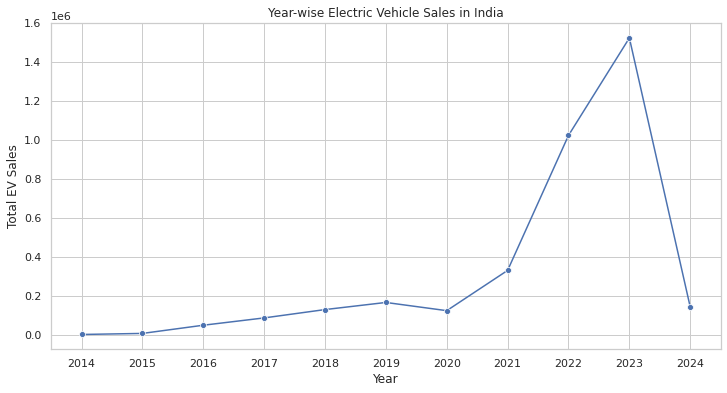

In [17]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly_sales,
    x="Year",
    y="EV_Sales_Quantity",
    marker="o"
)

plt.title("Year-wise Electric Vehicle Sales in India")
plt.xlabel("Year")
plt.ylabel("Total EV Sales")

plt.xticks(yearly_sales["Year"])

plt.show()

In [18]:
# ==========================================
# CELL 12 - YEAR-OVER-YEAR GROWTH
# ==========================================

yearly_sales["YoY_Growth_%"] = (
    yearly_sales["EV_Sales_Quantity"]
    .pct_change() * 100
)

display(yearly_sales)

,Year,EV_Sales_Quantity,YoY_Growth_%
0,2014,2392.0,NaN
1,2015,7805.0,226.295987
2,2016,49855.0,538.757207
3,2017,87420.0,75.348511
4,2018,130254.0,48.997941
5,2019,166819.0,28.072075
6,2020,124684.0,-25.257914
7,2021,331498.0,165.870521
8,2022,1024723.0,209.118909
9,2023,1525179.0,48.838174


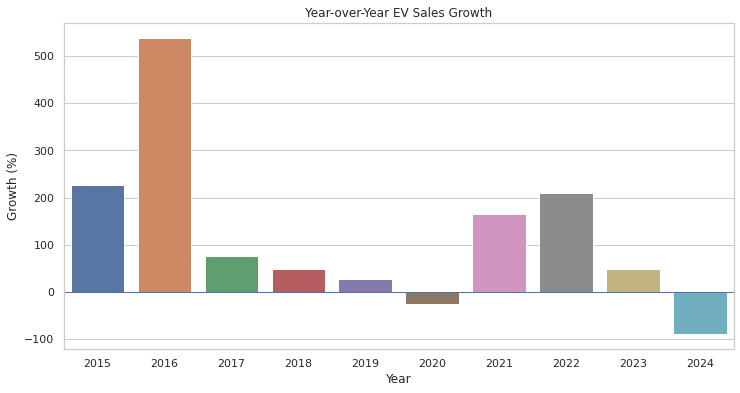

In [19]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=yearly_sales.iloc[1:],
    x="Year",
    y="YoY_Growth_%"
)

plt.axhline(0, linewidth=1)

plt.title("Year-over-Year EV Sales Growth")
plt.xlabel("Year")
plt.ylabel("Growth (%)")

plt.show()

In [20]:
# ==========================================
# CELL 13 - MONTHLY EV SALES
# ==========================================

month_order = {
    "jan": 1,
    "feb": 2,
    "mar": 3,
    "apr": 4,
    "may": 5,
    "jun": 6,
    "jul": 7,
    "aug": 8,
    "sep": 9,
    "oct": 10,
    "nov": 11,
    "dec": 12
}

df["Month_Number"] = (
    df["Month_Name"]
    .astype(str)
    .str.lower()
    .map(month_order)
)

monthly_sales = (
    df.groupby(
        ["Month_Number", "Month_Name"],
        observed=True
    )["EV_Sales_Quantity"]
    .sum()
    .reset_index()
    .sort_values("Month_Number")
)

display(monthly_sales)

,Month_Number,Month_Name,EV_Sales_Quantity
0,1,jan,360703.0
1,2,feb,228739.0
2,3,mar,299888.0
3,4,apr,232194.0
4,5,may,262747.0
5,6,jun,229754.0
6,7,jul,270473.0
7,8,aug,294022.0
8,9,sep,313433.0
9,10,oct,355083.0


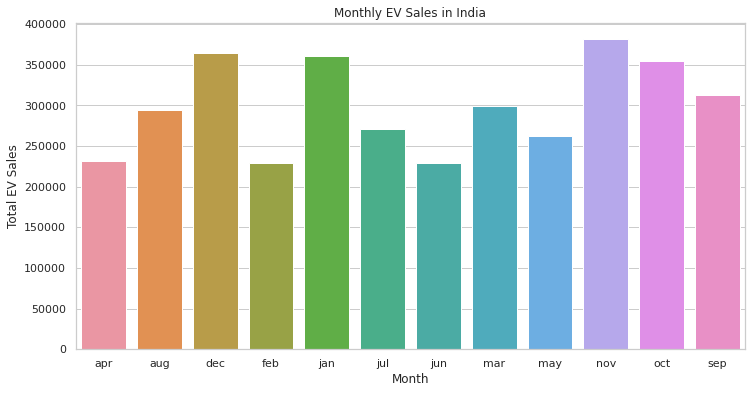

In [21]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=monthly_sales,
    x="Month_Name",
    y="EV_Sales_Quantity"
)

plt.title("Monthly EV Sales in India")
plt.xlabel("Month")
plt.ylabel("Total EV Sales")

plt.show()

In [22]:
# ==========================================
# CELL 14 - STATE-WISE SALES
# ==========================================

state_sales = (
    df.groupby("State", observed=True)["EV_Sales_Quantity"]
    .sum()
    .sort_values(ascending=False)
)

display(state_sales)

State
Uttar Pradesh               732074.0
Maharashtra                 401535.0
Karnataka                   315498.0
Delhi                       268538.0
Rajasthan                   228573.0
Bihar                       213465.0
Tamil Nadu                  206902.0
Gujarat                     176713.0
Assam                       151917.0
Kerala                      133246.0
Madhya Pradesh              133182.0
Odisha                       86823.0
Haryana                      85250.0
West Bengal                  78112.0
Andhra Pradesh               77356.0
Chhattisgarh                 75275.0
Uttarakhand                  57606.0
Punjab                       49285.0
Jharkhand                    47871.0
Tripura                      18346.0
Goa                          17382.0
Jammu and Kashmir            16840.0
Chandigarh                   11453.0
Puducherry                    5139.0
Himachal Pradesh              2886.0
Manipur                       1284.0
DNH and DD                     4

In [23]:
# ==========================================
# CELL 15 - TOP 10 STATES
# ==========================================

top10_states = state_sales.head(10)

display(top10_states)

State
Uttar Pradesh    732074.0
Maharashtra      401535.0
Karnataka        315498.0
Delhi            268538.0
Rajasthan        228573.0
Bihar            213465.0
Tamil Nadu       206902.0
Gujarat          176713.0
Assam            151917.0
Kerala           133246.0
Name: EV_Sales_Quantity, dtype: float64

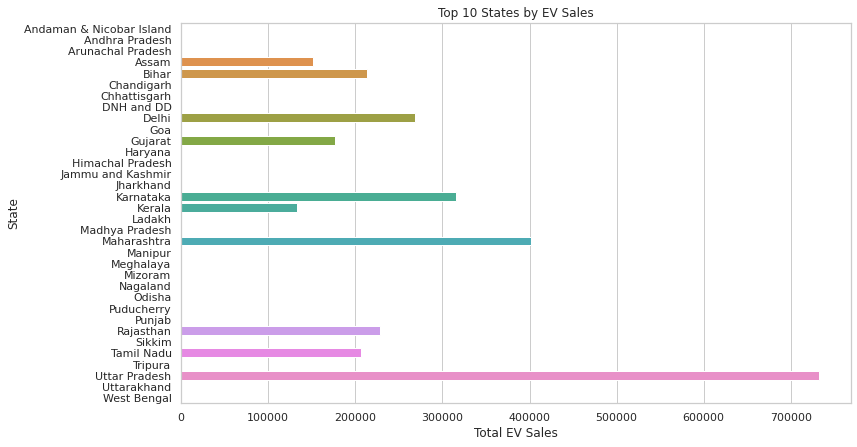

In [24]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=top10_states.values,
    y=top10_states.index
)

plt.title("Top 10 States by EV Sales")
plt.xlabel("Total EV Sales")
plt.ylabel("State")

plt.show()

In [25]:
# ==========================================
# CELL 16 - BOTTOM 10 STATES
# ==========================================

bottom10_states = (
    state_sales
    .tail(10)
    .sort_values()
)

display(bottom10_states)

State
Sikkim                         4.0
Arunachal Pradesh             40.0
Nagaland                      52.0
Ladakh                        88.0
Andaman & Nicobar Island     202.0
Meghalaya                    208.0
Mizoram                      235.0
DNH and DD                   431.0
Manipur                     1284.0
Himachal Pradesh            2886.0
Name: EV_Sales_Quantity, dtype: float64

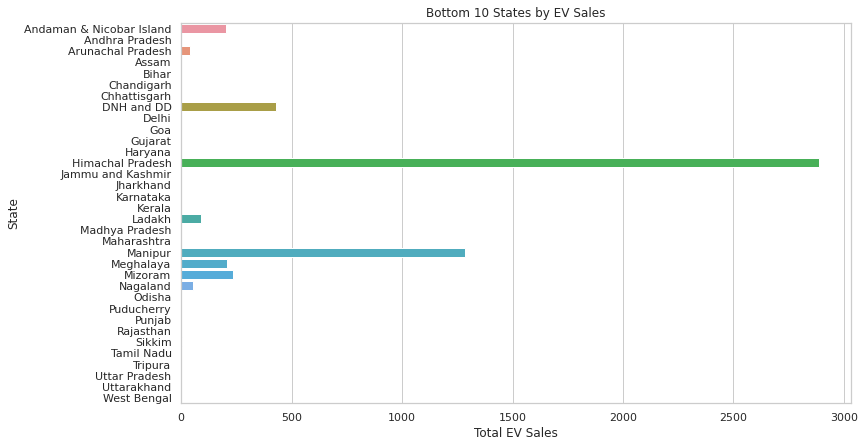

In [26]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=bottom10_states.values,
    y=bottom10_states.index
)

plt.title("Bottom 10 States by EV Sales")
plt.xlabel("Total EV Sales")
plt.ylabel("State")

plt.show()

Vehicle_Category
2-Wheelers    1808105.0
3-Wheelers    1620310.0
4-Wheelers     149775.0
Others           8612.0
Bus              7009.0
Name: EV_Sales_Quantity, dtype: float64

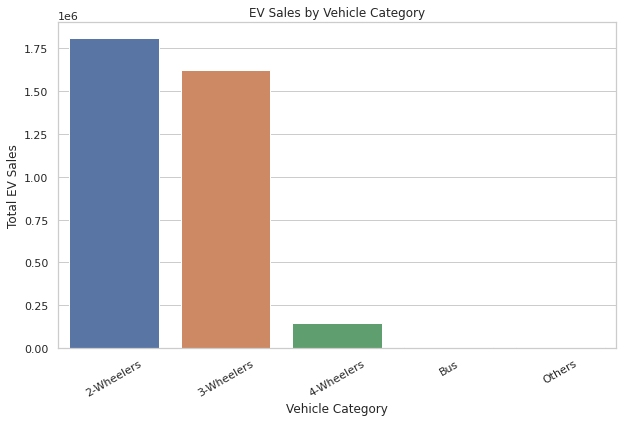

In [27]:
# ==========================================
# CELL 17 - VEHICLE CATEGORY ANALYSIS
# ==========================================

category_sales = (
    df.groupby(
        "Vehicle_Category",
        observed=True
    )["EV_Sales_Quantity"]
    .sum()
    .sort_values(ascending=False)
)

display(category_sales)
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("EV Sales by Vehicle Category")
plt.xlabel("Vehicle Category")
plt.ylabel("Total EV Sales")

plt.xticks(rotation=30)

plt.show()

Vehicle_Type
2W_Personal           1796340.0
3W_Shared_LowSpeed    1408127.0
4W_Personal            130676.0
3W_Goods_LowSpeed       90656.0
3W_Shared               76132.0
3W_Goods                44974.0
4W_Shared               19099.0
2W_Shared               11765.0
Others                   8612.0
Bus                      7009.0
3W_Personal               421.0
Institution Bus             0.0
Name: EV_Sales_Quantity, dtype: float64

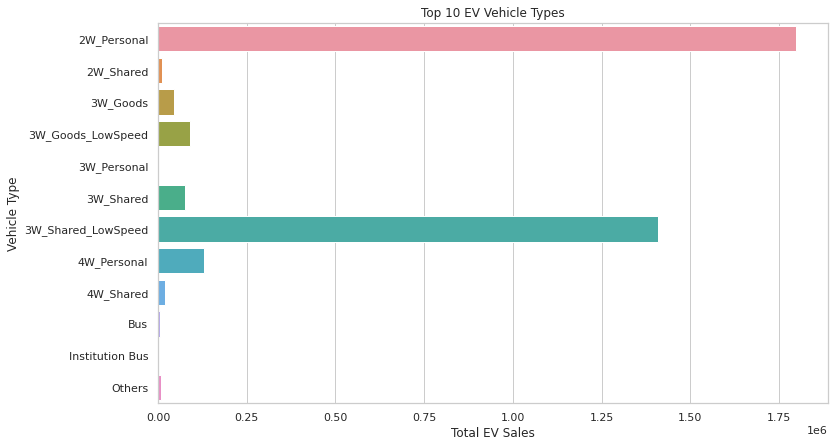

In [28]:
# ==========================================
# CELL 18 - VEHICLE TYPE ANALYSIS
# ==========================================

type_sales = (
    df.groupby(
        "Vehicle_Type",
        observed=True
    )["EV_Sales_Quantity"]
    .sum()
    .sort_values(ascending=False)
)

display(type_sales)
top10_types = type_sales.head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top10_types.values,
    y=top10_types.index
)

plt.title("Top 10 EV Vehicle Types")
plt.xlabel("Total EV Sales")
plt.ylabel("Vehicle Type")

plt.show()

Vehicle_Class
M-CYCLE/SCOOTER                      1697373.0
E-RICKSHAW(P)                        1408127.0
MOTOR CAR                             130676.0
E-RICKSHAW WITH CART (G)               90656.0
THREE WHEELER (PASSENGER)              76132.0
MOPED                                  61253.0
THREE WHEELER (GOODS)                  44974.0
MOTORISED CYCLE (CC > 25CC)            36390.0
MOTOR CAB                              18681.0
MOTOR CYCLE/SCOOTER-USED FOR HIRE      11765.0
BUS                                     6891.0
GOODS CARRIER                           6322.0
M-CYCLE/SCOOTER-WITH SIDE CAR           1324.0
TRAILER (COMMERCIAL)                     565.0
CONSTRUCTION EQUIPMENT VEHICLE           484.0
Name: EV_Sales_Quantity, dtype: float64

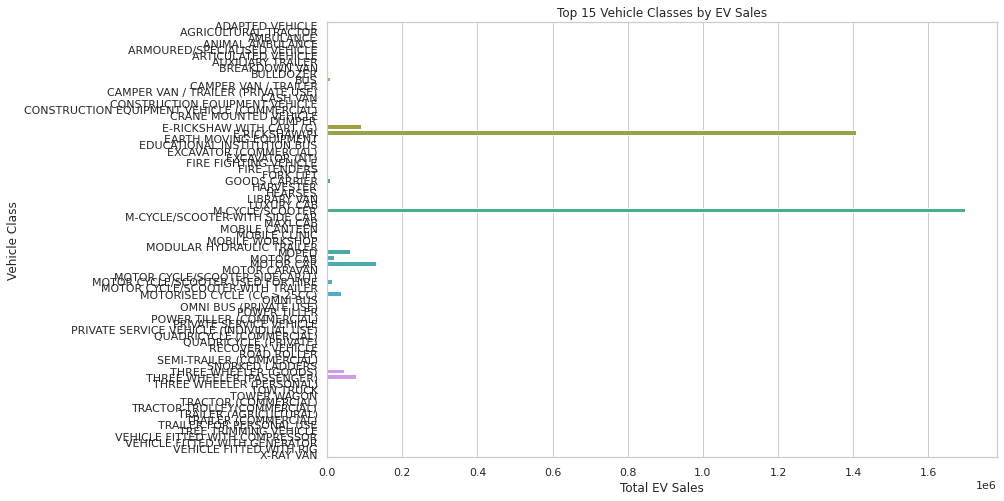

In [29]:
# ==========================================
# CELL 19 - VEHICLE CLASS ANALYSIS
# ==========================================

class_sales = (
    df.groupby(
        "Vehicle_Class",
        observed=True
    )["EV_Sales_Quantity"]
    .sum()
    .sort_values(ascending=False)
)

display(class_sales.head(15))
top15_classes = class_sales.head(15)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=top15_classes.values,
    y=top15_classes.index
)

plt.title("Top 15 Vehicle Classes by EV Sales")
plt.xlabel("Total EV Sales")
plt.ylabel("Vehicle Class")

plt.show()

Vehicle_Category,2-Wheelers,3-Wheelers,4-Wheelers,Bus,Others
State,,,,,
Andhra Pradesh,69020.0,4187.0,3264.0,120.0,765.0
Arunachal Pradesh,10.0,2.0,28.0,0.0,0.0
Assam,5208.0,145575.0,518.0,193.0,423.0
Andaman & Nicobar Island,31.0,30.0,99.0,40.0,2.0
Bihar,28116.0,184394.0,881.0,27.0,47.0
Chhattisgarh,48828.0,23139.0,1728.0,2.0,1578.0
Chandigarh,3395.0,6437.0,1501.0,80.0,40.0
DNH and DD,256.0,74.0,68.0,25.0,8.0
Delhi,85358.0,161868.0,19164.0,1731.0,417.0


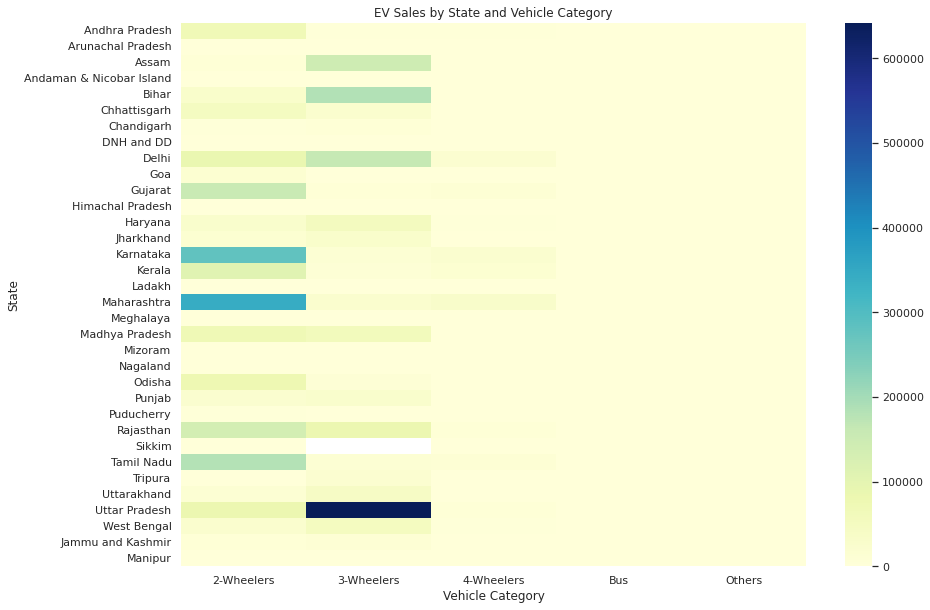

In [30]:
# ==========================================
# CELL 20 - STATE VS VEHICLE CATEGORY
# ==========================================

state_category = pd.pivot_table(
    df,
    values="EV_Sales_Quantity",
    index="State",
    columns="Vehicle_Category",
    aggfunc="sum",
    observed=True
)

display(state_category)
plt.figure(figsize=(14, 10))

sns.heatmap(
    state_category,
    cmap="YlGnBu"
)

plt.title("EV Sales by State and Vehicle Category")
plt.xlabel("Vehicle Category")
plt.ylabel("State")

plt.show()

Vehicle_Category,2-Wheelers,3-Wheelers,4-Wheelers,Bus,Others
Year,,,,,
2014,1679.0,12.0,498.0,3.0,200.0
2015,1447.0,5440.0,761.0,4.0,153.0
2016,1460.0,47352.0,692.0,5.0,346.0
2017,1528.0,83530.0,1108.0,17.0,1237.0
2018,17059.0,110451.0,1588.0,49.0,1107.0
2019,30357.0,134168.0,1666.0,506.0,122.0
2020,29110.0,91236.0,4201.0,88.0,49.0
2021,156196.0,159909.0,13002.0,1177.0,1214.0
2022,631090.0,352742.0,38170.0,1988.0,733.0


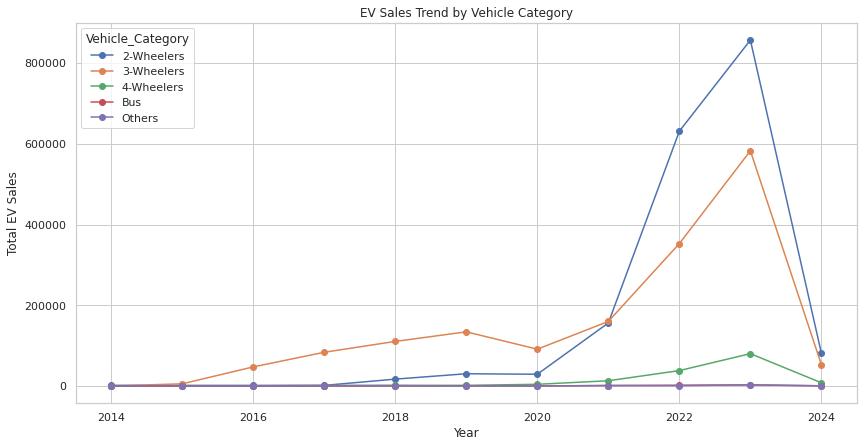

In [31]:
# ==========================================
# CELL 21 - YEAR VS VEHICLE CATEGORY
# ==========================================

year_category = pd.pivot_table(
    df,
    values="EV_Sales_Quantity",
    index="Year",
    columns="Vehicle_Category",
    aggfunc="sum",
    observed=True
)

display(year_category)
year_category.plot(
    figsize=(14, 7),
    marker="o"
)

plt.title("EV Sales Trend by Vehicle Category")
plt.xlabel("Year")
plt.ylabel("Total EV Sales")

plt.show()

In [32]:
# ==========================================
# CELL 22 - BEST STATE FOR EACH CATEGORY
# ==========================================

state_category_sales = (
    df.groupby(
        ["State", "Vehicle_Category"],
        observed=True
    )["EV_Sales_Quantity"]
    .sum()
    .reset_index()
)

idx = (
    state_category_sales
    .groupby("Vehicle_Category")["EV_Sales_Quantity"]
    .idxmax()
)

best_state_category = (
    state_category_sales
    .loc[idx]
    .sort_values(
        "EV_Sales_Quantity",
        ascending=False
    )
)

display(best_state_category)

,State,Vehicle_Category,EV_Sales_Quantity
153,Uttar Pradesh,3-Wheelers,641906.0
87,Maharashtra,2-Wheelers,342236.0
88,Maharashtra,4-Wheelers,32317.0
134,Tamil Nadu,Others,1845.0
41,Delhi,Bus,1731.0


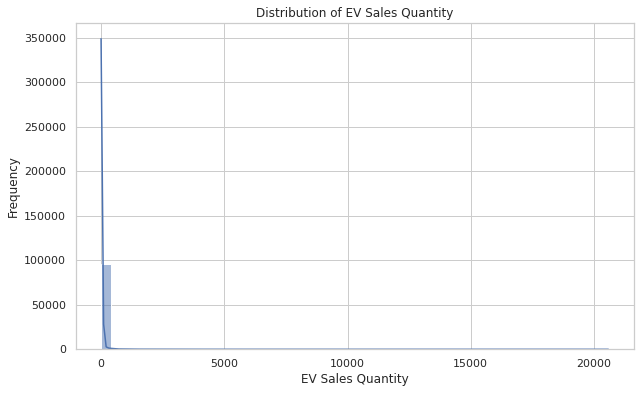

In [33]:
# ==========================================
# CELL 23 - SALES DISTRIBUTION
# ==========================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["EV_Sales_Quantity"],
    bins=50,
    kde=True
)

plt.title("Distribution of EV Sales Quantity")
plt.xlabel("EV Sales Quantity")
plt.ylabel("Frequency")

plt.show()

In [34]:
# ==========================================
# CELL 24 - MACHINE LEARNING PREPARATION
# ==========================================

df_ml = df.copy()

# Extract date features
df_ml["Month"] = df_ml["Date"].dt.month
df_ml["Day"] = df_ml["Date"].dt.day

features = [
    "Year",
    "Month",
    "Day",
    "State",
    "Vehicle_Class",
    "Vehicle_Category",
    "Vehicle_Type"
]

target = "EV_Sales_Quantity"

X = df_ml[features]
y = df_ml[target]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,Year,Month,Day,State,Vehicle_Class,Vehicle_Category,Vehicle_Type
0,2014,1,1,Andhra Pradesh,ADAPTED VEHICLE,Others,Others
1,2014,1,1,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others
2,2014,1,1,Andhra Pradesh,AMBULANCE,Others,Others
3,2014,1,1,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others
4,2014,1,1,Andhra Pradesh,BUS,Bus,Bus



Target:


0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: EV_Sales_Quantity, dtype: float64

In [35]:
# ==========================================
# CELL 25 - ENCODING
# ==========================================

X = pd.get_dummies(
    X,
    columns=[
        "State",
        "Vehicle_Class",
        "Vehicle_Category",
        "Vehicle_Type"
    ],
    drop_first=True
)

print("Encoded dataset shape:")
print(X.shape)

Encoded dataset shape:
(96845, 123)


In [36]:
# ==========================================
# CELL 26 - TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (77476, 123)
Testing data : (19369, 123)


In [38]:
# ==========================================
# CELL 27 - RANDOM FOREST MODEL
# ==========================================

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [39]:
# ==========================================
# CELL 28 - PREDICTIONS
# ==========================================

y_pred = model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [40]:

# ==========================================
# CELL 29 - MODEL EVALUATION
# ==========================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("======================================")
print("       RANDOM FOREST RESULTS")
print("======================================")

print("MAE  :", round(mae, 2))
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 4))

       RANDOM FOREST RESULTS
MAE  : 10.73
MSE  : 17051.59
RMSE : 130.58
R²   : 0.9345


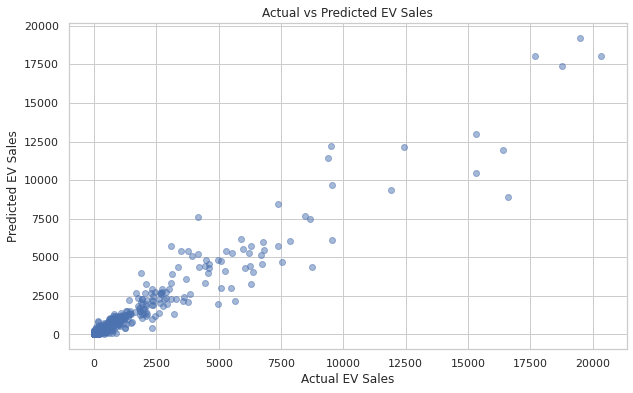

In [41]:
# ==========================================
# CELL 30 - ACTUAL VS PREDICTED
# ==========================================

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual EV Sales")
plt.ylabel("Predicted EV Sales")

plt.title("Actual vs Predicted EV Sales")

plt.show()

Year                               0.301859
State_Uttar Pradesh                0.169389
State_Maharashtra                  0.153997
State_Karnataka                    0.063386
Month                              0.053953
Vehicle_Class_M-CYCLE/SCOOTER      0.033880
State_Tamil Nadu                   0.029112
Vehicle_Type_3W_Shared_LowSpeed    0.028351
Vehicle_Class_E-RICKSHAW(P)        0.028334
State_Gujarat                      0.023989
State_Kerala                       0.019223
State_Rajasthan                    0.018139
State_Bihar                        0.017367
State_Delhi                        0.015560
State_Assam                        0.010165
State_Madhya Pradesh               0.008615
State_Odisha                       0.006808
State_Andhra Pradesh               0.005102
State_Chhattisgarh                 0.002642
State_Haryana                      0.001933
dtype: float64

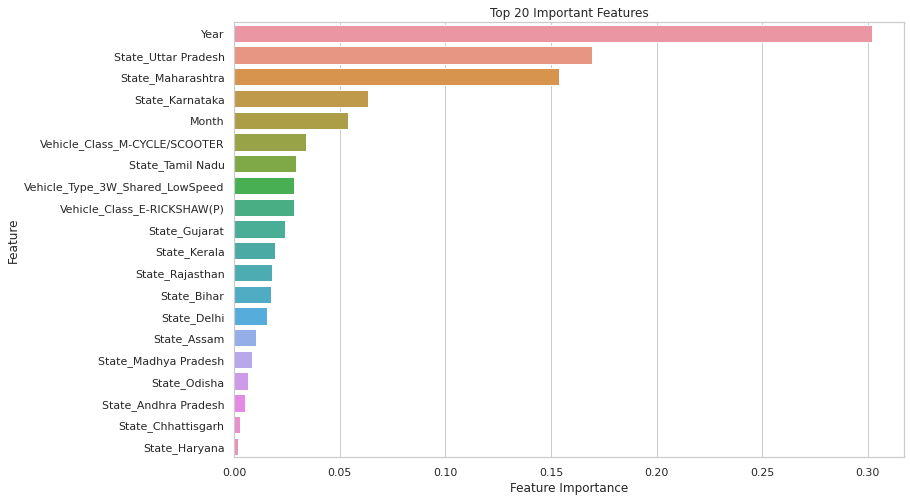

In [42]:
# ==========================================
# CELL 31 - FEATURE IMPORTANCE
# ==========================================

feature_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

feature_importance = (
    feature_importance
    .sort_values(ascending=False)
)

display(feature_importance.head(20))
top_features = feature_importance.head(20)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title("Top 20 Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [43]:
# ==========================================
# CELL 32 - BUSINESS INSIGHTS
# ==========================================

total_sales = df["EV_Sales_Quantity"].sum()

best_state = state_sales.idxmax()
best_state_sales = state_sales.max()

best_category = category_sales.idxmax()
best_category_sales = category_sales.max()

best_vehicle_type = type_sales.idxmax()
best_vehicle_type_sales = type_sales.max()

best_year_index = yearly_sales[
    "EV_Sales_Quantity"
].idxmax()

best_year = yearly_sales.loc[
    best_year_index,
    "Year"
]

best_year_sales = yearly_sales.loc[
    best_year_index,
    "EV_Sales_Quantity"
]

print("==============================================")
print("        ELECTRIC VEHICLE SALES INSIGHTS")
print("==============================================")

print(f"Total EV Sales       : {total_sales:,.0f}")

print(f"Top State            : {best_state}")
print(f"Top State Sales      : {best_state_sales:,.0f}")

print(f"Top Vehicle Category : {best_category}")
print(f"Category Sales       : {best_category_sales:,.0f}")

print(f"Top Vehicle Type     : {best_vehicle_type}")
print(f"Vehicle Type Sales   : {best_vehicle_type_sales:,.0f}")

print(f"Best Sales Year      : {best_year}")
print(f"Best Year Sales      : {best_year_sales:,.0f}")

print("\n==============================================")
print("              MODEL PERFORMANCE")
print("==============================================")

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

        ELECTRIC VEHICLE SALES INSIGHTS
Total EV Sales       : 3,593,811
Top State            : Uttar Pradesh
Top State Sales      : 732,074
Top Vehicle Category : 2-Wheelers
Category Sales       : 1,808,105
Top Vehicle Type     : 2W_Personal
Vehicle Type Sales   : 1,796,340
Best Sales Year      : 2023
Best Year Sales      : 1,525,179

              MODEL PERFORMANCE
MAE  : 10.73
RMSE : 130.58
R²   : 0.9345
